In [1]:
# Parameters

#name_import = "H_I-6563"
#line        = r'H$\alpha$'
#line_       = "H_I"

In [2]:
# Parameters
name_import = "Ar_III-7136"
line = "[Ar III] 7136"
line_ = "Ar_III"


In [3]:
import time
start_time=time.time()
from pathlib import Path
import sys
import json
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
#name_export = name_import

In [5]:
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules")
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse")

# Add path to py_modules 
#sys.path.append(str(Path().resolve().parents[0] / 'py_modules')) # 1 level up = project root

# Add path to pipeline_config.py
#sys.path.append(str(Path().resolve().parents[0]))  # 1 level up = project root

# Import from pipeline_config and py_modules
from pipeline_config import OBSERVATIONS_DIR, MAPS_DIR, FIGS_DIR

import region_observations_props as rop
from astrometry_utils import get_radec_from_map

In [6]:
rop.pc, rop.s0, rop.pixel_scale, rop.ra_star, rop.dec_star, rop.name_star

(0.0019877360925490972,
 0.0007596443665792729,
 0.2,
 83.81875,
 -5.3897222,
 '$\\theta^1$ Ori C')

In [7]:
# Input FITS files
flux_path    = OBSERVATIONS_DIR / f'linesum-{name_import}.fits'
radvel_path  = OBSERVATIONS_DIR / f'mean-{name_import}-patfixx.fits'

# Open files
flux    = fits.open(flux_path)
rad_vel = fits.open(radvel_path)

In [8]:
# flux[0].info()
# flux[0].header

In [9]:
sb = flux[0].data.astype(float)
vv = rad_vel[1].data.astype(float)

In [10]:
trim = (slice(0, 1476),slice(0, 1766))
vv = vv[trim]

In [11]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv) | (sb < 0.0)

sb[m] = 0.0
vv[m] = np.nanmean(vv)
sb /= sb.max()

good = (~m) & (sb > 0.001)

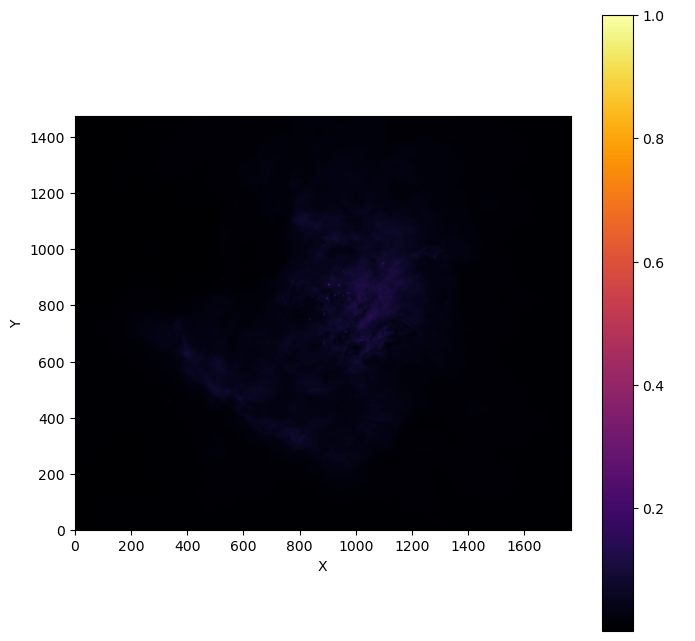

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(sb, cmap='inferno')

cbar = plt.colorbar()
plt.clim(0.001,1)
cbar.set_label(' ', rotation=270, labelpad=15)  

ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.gca().invert_yaxis()

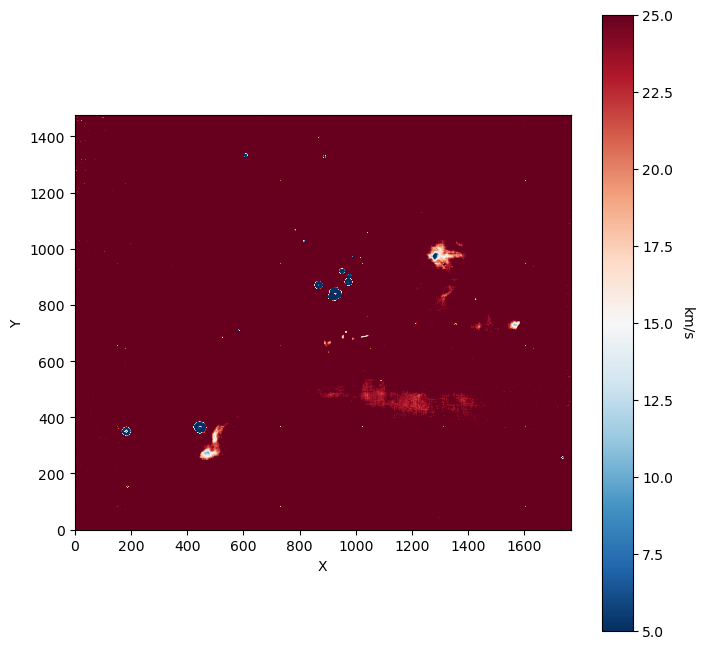

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(vv, cmap='RdBu_r')

cbar = plt.colorbar()
plt.clim(5,25)
cbar.set_label('km/s', rotation=270, labelpad=15)  

ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.gca().invert_yaxis()

In [14]:
ra, dec, w,  x_star, y_star = get_radec_from_map(sb, rop.pixel_scale, rop.ra_star, rop.dec_star)

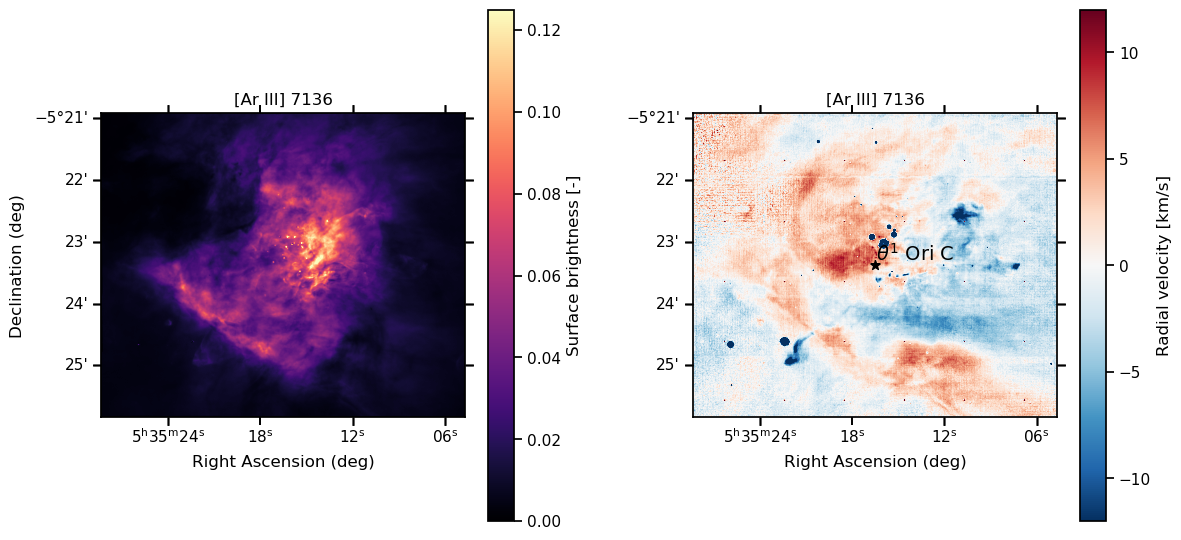

In [19]:
sns.set_context("notebook")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': w})

# Left plot: Surface brightness
im1 = ax1.imshow(sb, origin='lower', cmap='magma')
ax1.set_title(line)
ax1.set_xlabel('Right Ascension (deg)')
ax1.set_ylabel('Declination (deg)')
cbar1 = plt.colorbar(im1, ax=ax1, label='Surface brightness [-]')
im1.set_clim(0, .125)
#ax1.text(0.3, 0.9, r'S(' + line + ')',
#         verticalalignment='bottom', horizontalalignment='right',
#         transform=ax1.transAxes,
#         color='white', fontsize=20)

# Right plot: Radial velocity
im2 = ax2.imshow(vv-vv.mean(), origin='lower', cmap='RdBu_r')
ax2.set_title(line)
ax2.set_xlabel('Right Ascension (deg)')
ax2.set_ylabel(' ')
cbar2 = plt.colorbar(im2, ax=ax2, label='Radial velocity [km/s]')
im2.set_clim(-12, 12)
ax2.scatter(x_star, y_star, color='black', s=50, marker='*')
ax2.text(x_star + 5, y_star + 5, rop.name_star, color='black', fontsize=14,
        ha='left', va='bottom')

plt.tight_layout()

plt.savefig(FIGS_DIR / f"{name_import}.png", bbox_inches='tight')
plt.show()


In [16]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 15.070266246795654 seconds ---
